File                                              Mean      Std  Mean OK   Std OK
--------------------------------------------------------------------------------
Position01Channel01Frame000001.tif              0.0000   1.8217     True    False
Position01Channel01Frame000002.tif             -0.0000   1.7992     True    False
Position01Channel01Frame000003.tif             -0.0000   1.8203     True    False
Position01Channel01Frame000004.tif              0.0000   1.8470     True    False
Position01Channel01Frame000005.tif             -0.0000   1.8564     True    False


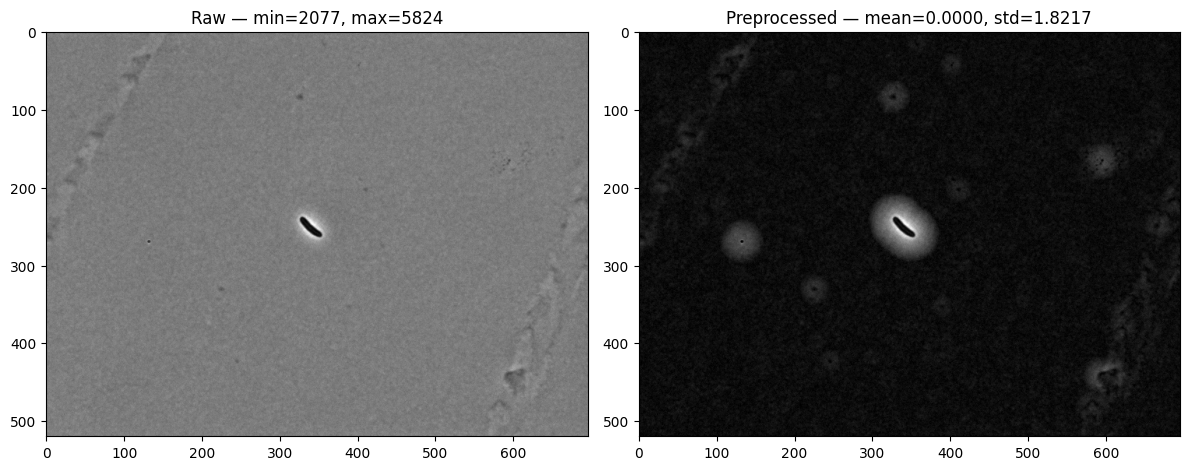


Figure saved.


In [3]:
import tifffile
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../src')

# Force reload
if 'preprocessing' in sys.modules:
    del sys.modules['preprocessing']

from preprocessing import preprocess_image

tif_files = [
    '../data/raw/delta/tests/data/movie_2D_tif/Position01Channel01Frame000001.tif',
    '../data/raw/delta/tests/data/movie_2D_tif/Position01Channel01Frame000002.tif',
    '../data/raw/delta/tests/data/movie_2D_tif/Position01Channel01Frame000003.tif',
    '../data/raw/delta/tests/data/movie_2D_tif/Position01Channel01Frame000004.tif',
    '../data/raw/delta/tests/data/movie_2D_tif/Position01Channel01Frame000005.tif',
]

print(f"{'File':<45} {'Mean':>8} {'Std':>8} {'Mean OK':>8} {'Std OK':>8}")
print("-" * 80)

results = []
for path in tif_files:
    img_raw = tifffile.imread(path)
    img_clean = preprocess_image(img_raw)
    mean = img_clean.mean()
    std = img_clean.std()
    mean_ok = abs(mean) < 0.5
    std_ok = abs(std - 1.0) < 0.3
    results.append((path, img_raw, img_clean, mean, std))
    fname = path.split('/')[-1]
    print(f"{fname:<45} {mean:>8.4f} {std:>8.4f} {str(mean_ok):>8} {str(std_ok):>8}")

# Save before/after figure for first image
path, img_raw, img_clean, mean, std = results[0]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_raw, cmap='gray')
axes[0].set_title(f'Raw — min={img_raw.min()}, max={img_raw.max()}')
axes[1].imshow(img_clean, cmap='gray')
axes[1].set_title(f'Preprocessed — mean={mean:.4f}, std={std:.4f}')
plt.tight_layout()
plt.savefig('../outputs/figures/week3_preprocessing_fixed.png', dpi=150)
plt.show()
print("\nFigure saved.")